In [1]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/opt/anaconda3/envs/solar-predict/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
    pad_to_32,
    crop_back
)
from src.plot import(
    plot_full_images_from_loader,
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)

/opt/anaconda3/envs/solar-predict/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [3]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
)

print("Saved:", out)
print("Final shape:", shape)


NameError: name 'bands_npz_name' is not defined

In [4]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (7941, 12, 50, 50)
y shape: (7941, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.054774634540081024 max 1.0


In [7]:
T = X.shape[0]
idx_train, idx_val, idx_test = train_val_test_split_indices(T, 0.7, 0.15, seed=42)

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [8]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_stats_day.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)


channel_min: [189.45    188.25    188.85999 187.95999 209.95    188.38    187.03
 186.91    189.1      38.89      0.        0.     ]
channel_max: [258.32    267.72    272.69998 306.74    278.75    311.07    309.61
 302.5     281.1      40.57    804.1716    1.     ]


In [9]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = smp.UnetPlusPlus(
    encoder_name="resnet18", # "resnet18", "resnet34", "resnet50"
    encoder_weights=None,
    in_channels=12,   # we use 10 bands
    classes=1,        # CSI map
    activation = "sigmoid",  # regression
)
model = model.to(device)

In [11]:
import torch.nn as nn
import torch.optim as optim
import kornia


criterion_reg  = nn.SmoothL1Loss(beta=0.03)  # sharper than 0.05
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")

def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).view(1,1,3,3)
    lp = torch.nn.functional.conv2d(pred, k, padding=1)
    lt = torch.nn.functional.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

def combined_loss(y_pred, y_true, w_reg=0.7, w_ssim=0.1, w_grad=0.15, w_lap=0.05):
    return (
        w_reg * criterion_reg(y_pred, y_true)
        + w_ssim * criterion_ssim(y_pred, y_true)
        + w_grad * grad_loss(y_pred, y_true)
        + w_lap * lap_loss(y_pred, y_true)
    )


optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,          
    weight_decay=1e-4
)

# LR scheduler: reduce LR if val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,       # halve LR
    patience=3,       # if no improvement for 3 epochs
    min_lr=1e-6
)

num_epochs = 60
best_val_loss = np.inf
best_state = None
patience_es = 8     # early stopping patience
es_counter = 0
criterion = combined_loss
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    # Step LR scheduler based on val loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f} | lr {optimizer.param_groups[0]['lr']:.1e}")

    # Early stopping check
    if val_loss < best_val_loss - 1e-5:  # small tolerance
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        es_counter = 0
    else:
        es_counter += 1
        if es_counter >= patience_es:
            print(f"Early stopping at epoch {epoch}")
            break

# restore best model
if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01 | train 0.1231 | val 0.1220 | lr 3.0e-04
Epoch 02 | train 0.1113 | val 0.1221 | lr 3.0e-04
Epoch 03 | train 0.1070 | val 0.1356 | lr 3.0e-04
Epoch 04 | train 0.1042 | val 0.1400 | lr 3.0e-04
Epoch 05 | train 0.1017 | val 0.1114 | lr 3.0e-04
Epoch 06 | train 0.0995 | val 0.1150 | lr 3.0e-04
Epoch 07 | train 0.1003 | val 0.1001 | lr 3.0e-04
Epoch 08 | train 0.0988 | val 0.0948 | lr 3.0e-04
Epoch 09 | train 0.0961 | val 0.1098 | lr 3.0e-04
Epoch 10 | train 0.0961 | val 0.1109 | lr 3.0e-04
Epoch 11 | train 0.0960 | val 0.1087 | lr 3.0e-04
Epoch 12 | train 0.0947 | val 0.0998 | lr 1.5e-04
Epoch 13 | train 0.0903 | val 0.0902 | lr 1.5e-04
Epoch 14 | train 0.0896 | val 0.1283 | lr 1.5e-04
Epoch 15 | train 0.0883 | val 0.1070 | lr 1.5e-04
Epoch 16 | train 0.0896 | val 0.0914 | lr 1.5e-04
Epoch 17 | train 0.0879 | val 0.1038 | lr 7.5e-05
Epoch 18 | train 0.0848 | val 0.1005 | lr 7.5e-05
Epoch 19 | train 0.0838 | val 0.0885 | lr 7.5e-05
Epoch 20 | train 0.0836 | val 0.0867 | lr 7.5e-05


In [12]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604


In [ ]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

In [13]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)

ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


In [16]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.130254
CSI_rRMSE: 0.183818
CSI_R2: 0.819233
CSI_MBE: -0.001009
CSI_MAE: 0.083949
CSI_mean_true: 0.708604
GHI_RMSE: 77.386383
GHI_rRMSE: 0.184878
GHI_R2: 0.922069
GHI_MBE: 2.751240
GHI_MAE: 46.415672
GHI_mean_true: 418.581726


In [17]:
PATH = "Model_checkpoint/Unet+_elevation_sig_no_twil.pth"
torch.save(model.state_dict(), PATH)

In [18]:
model = smp.UnetPlusPlus(
    encoder_name="resnet18", # "resnet18", "resnet34", "resnet50"
    encoder_weights=None,
    in_channels=12,   # we use 10 bands
    classes=1,        # CSI map
    activation = "sigmoid",  # regression
).to(device)
model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [19]:
device = torch.device('mps')
model = model.to(device)
y_pred_list = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_batch = y_batch.to(device).contiguous()
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)
        yb_hat = model(xb_pad)
        yb_hat = crop_back(yb_hat, h, w).contiguous()
        y_pred_list.append(yb_hat.cpu().numpy())  
y_pred = np.concatenate(y_pred_list, axis=0)         

In [20]:
y_pred_list[0].shape

(16, 1, 50, 50)

In [21]:
print("y_pred shape:", y_pred.shape)
print("CSI predcit: min", y_pred.min(), "max", y_pred.max(), "mean", y_pred.mean())

y_pred shape: (1192, 1, 50, 50)
CSI predcit: min 0.059342593 max 0.999987 mean 0.7075958


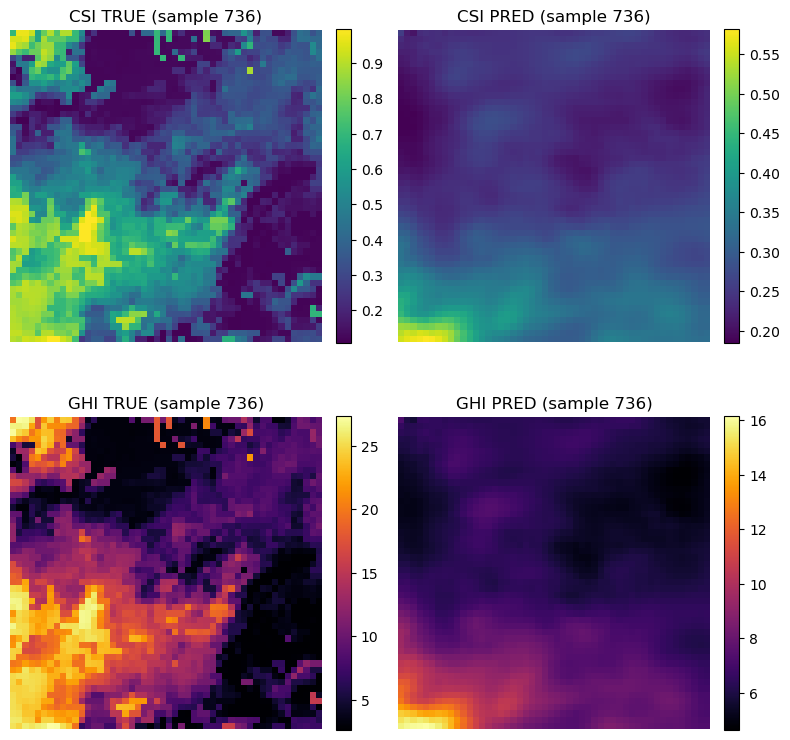

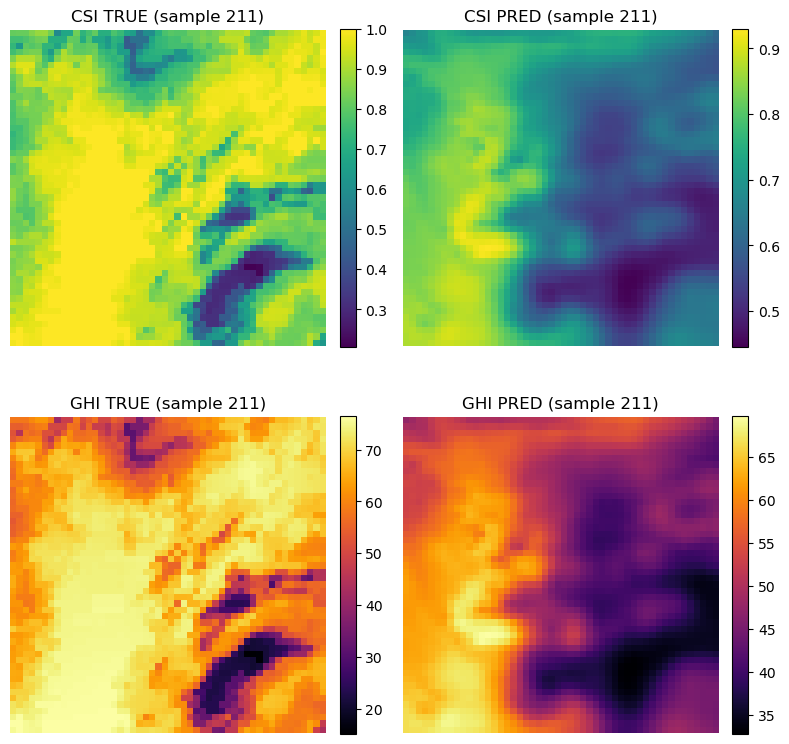

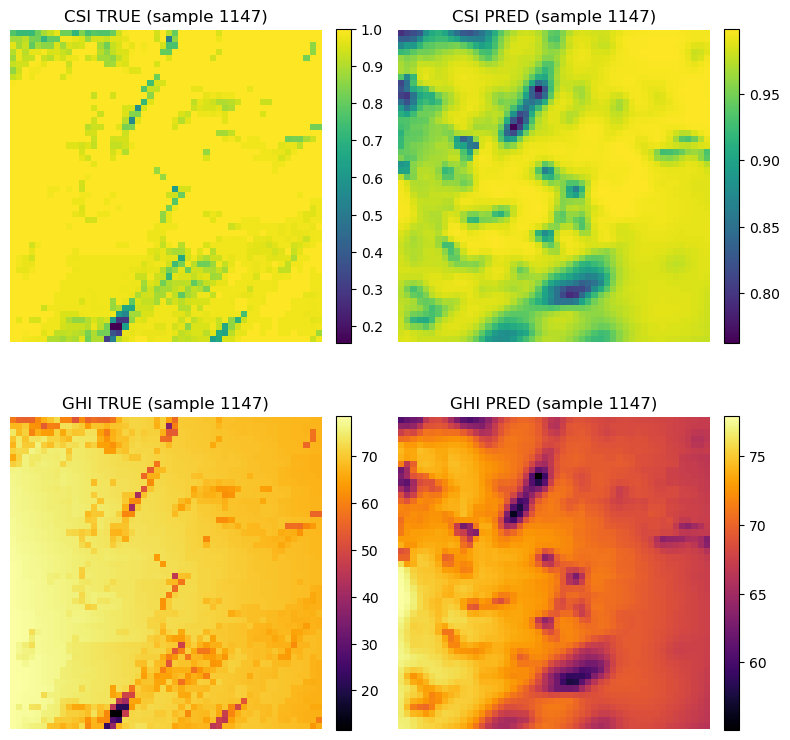

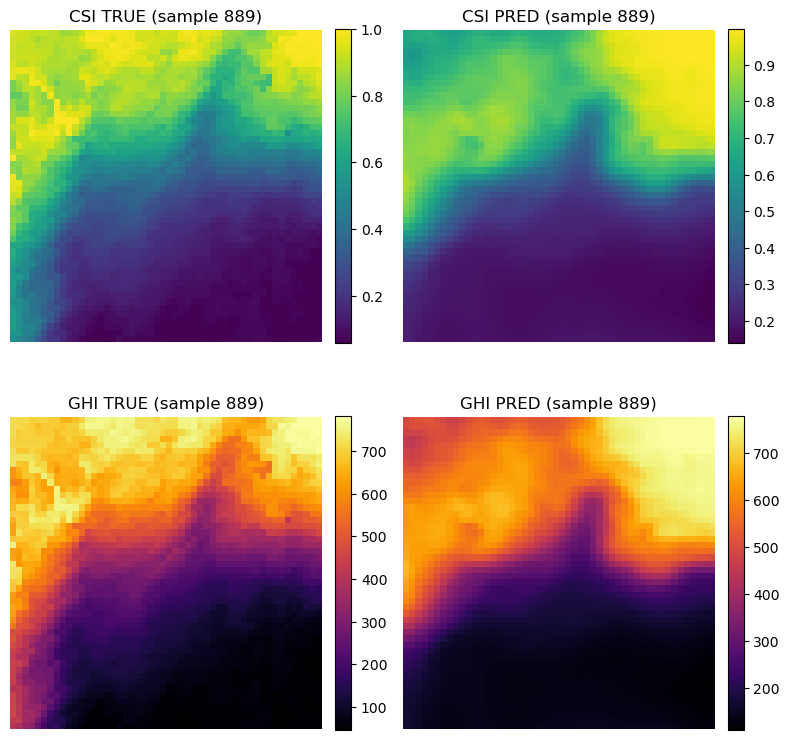

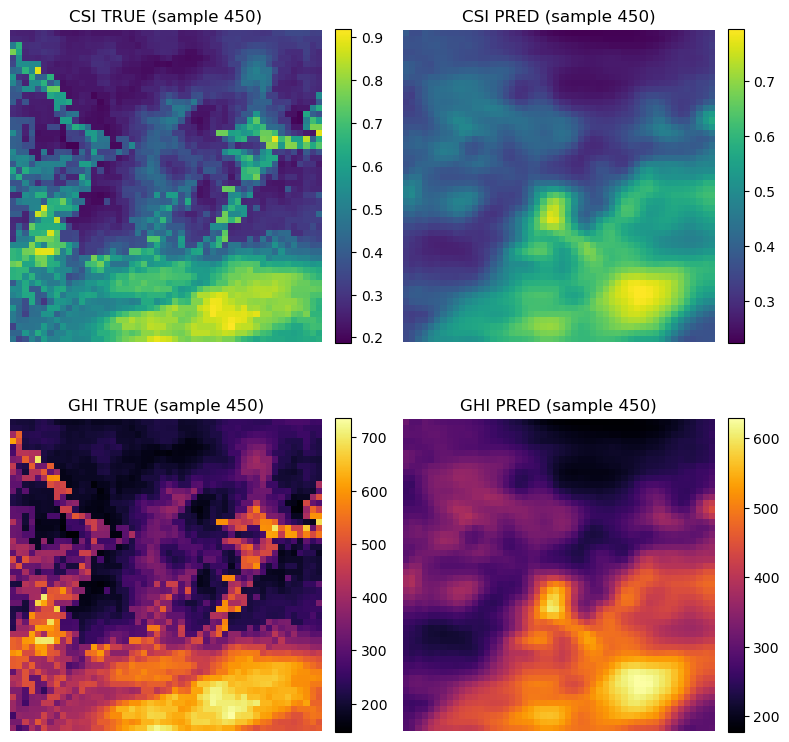

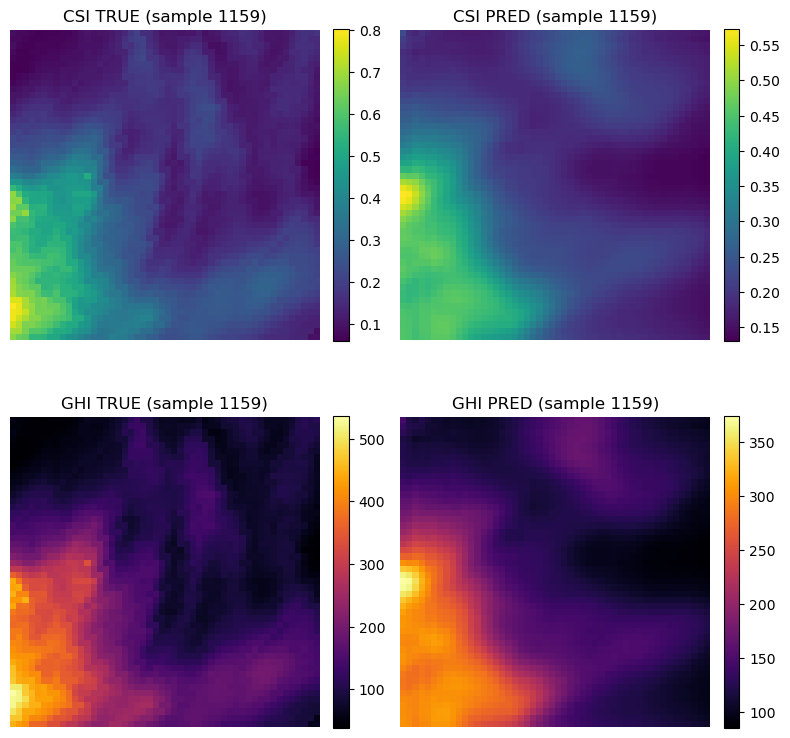

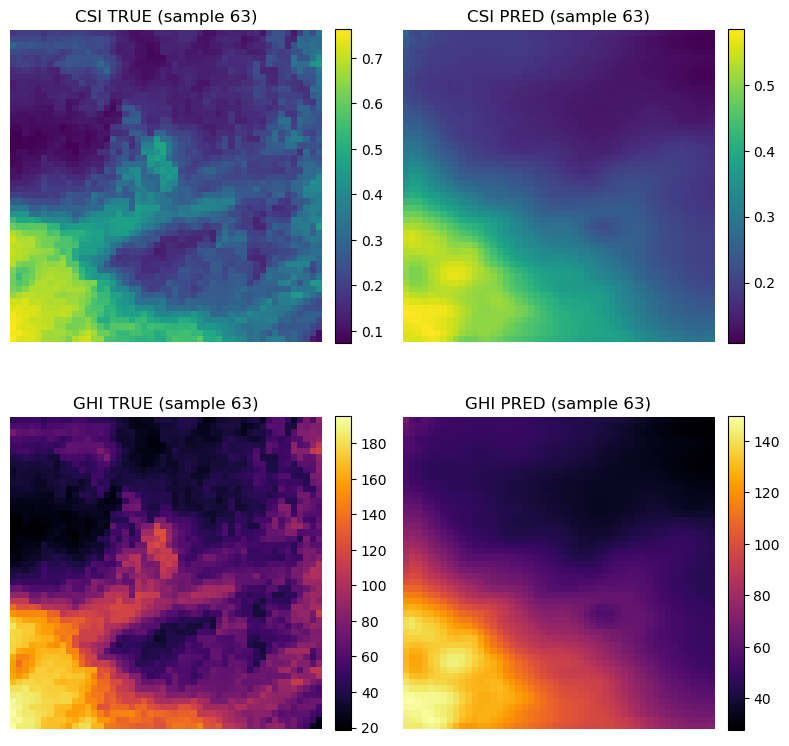

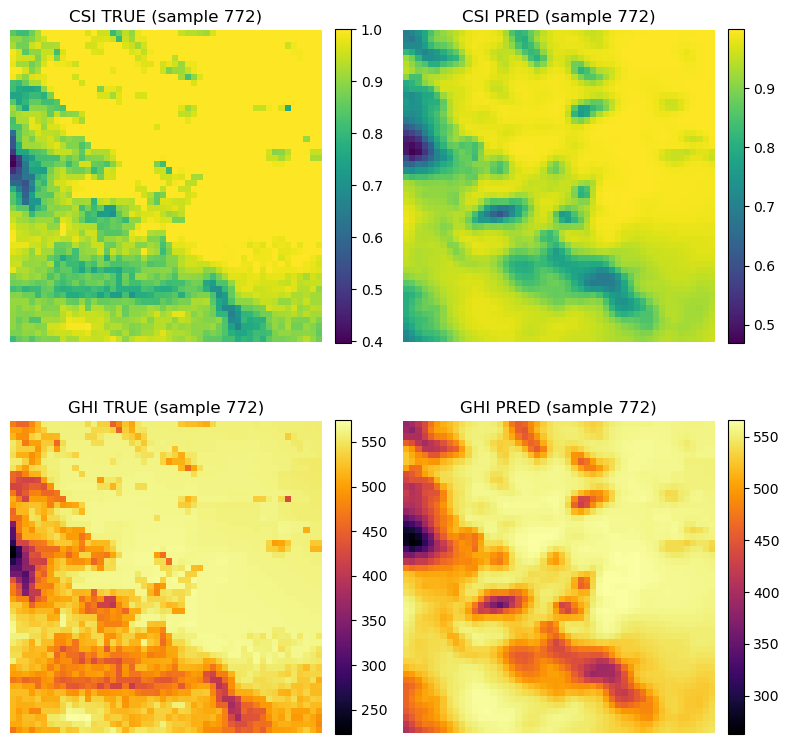

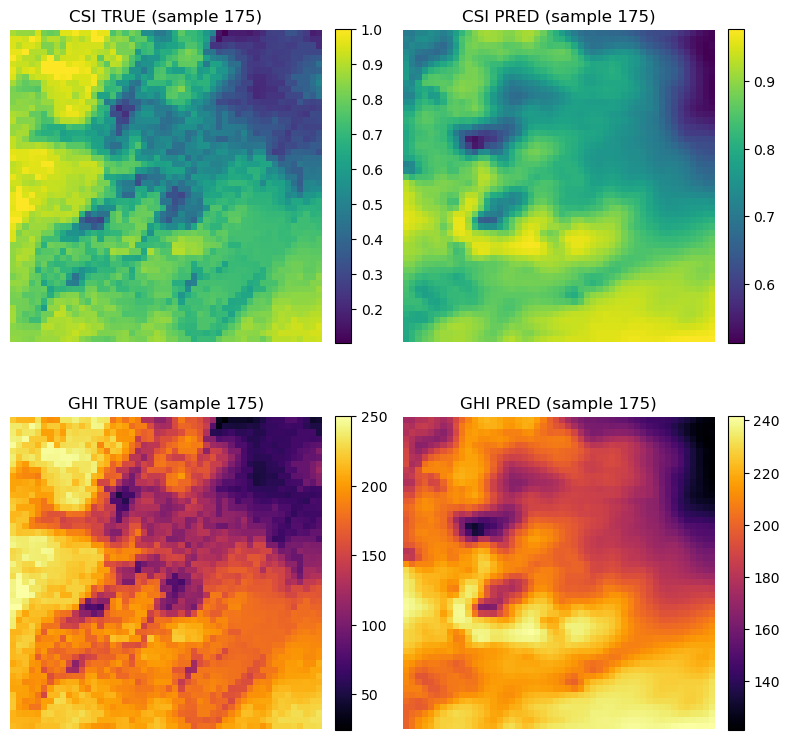

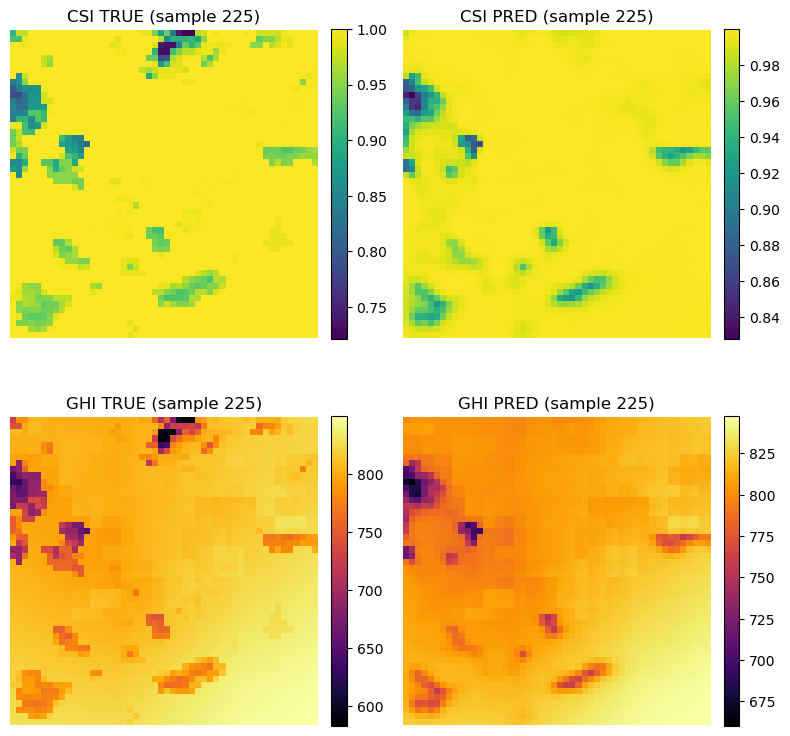

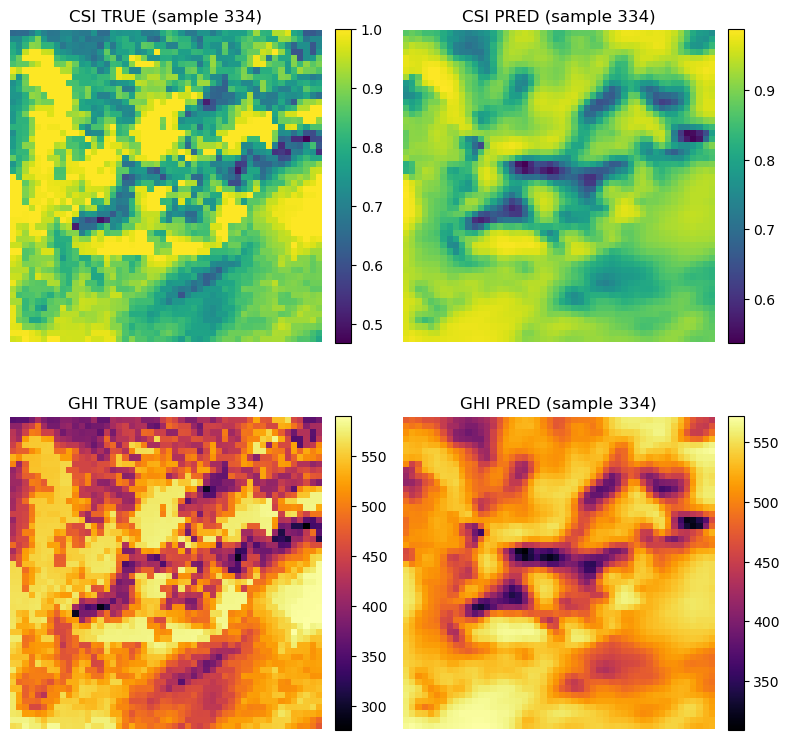

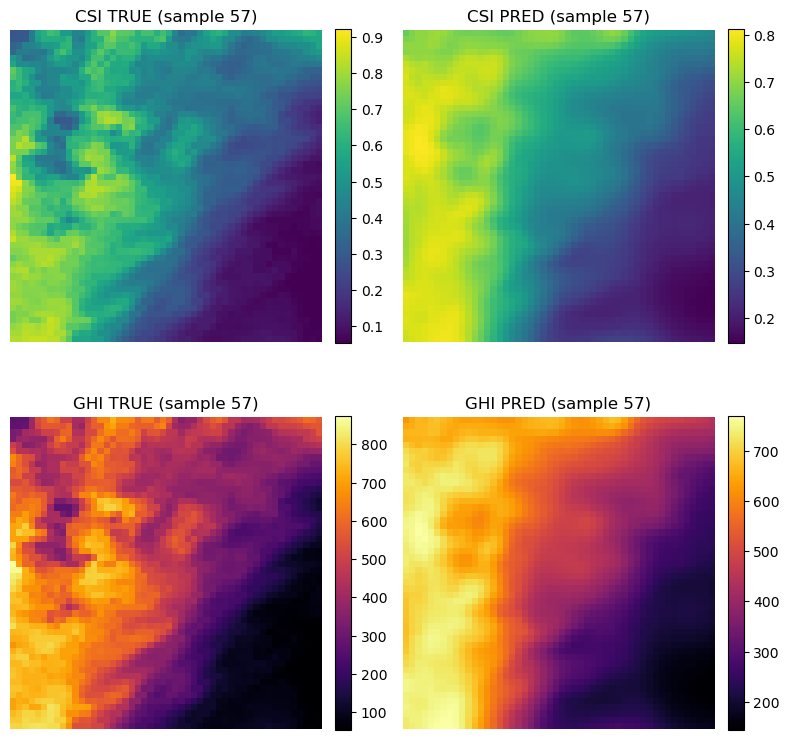

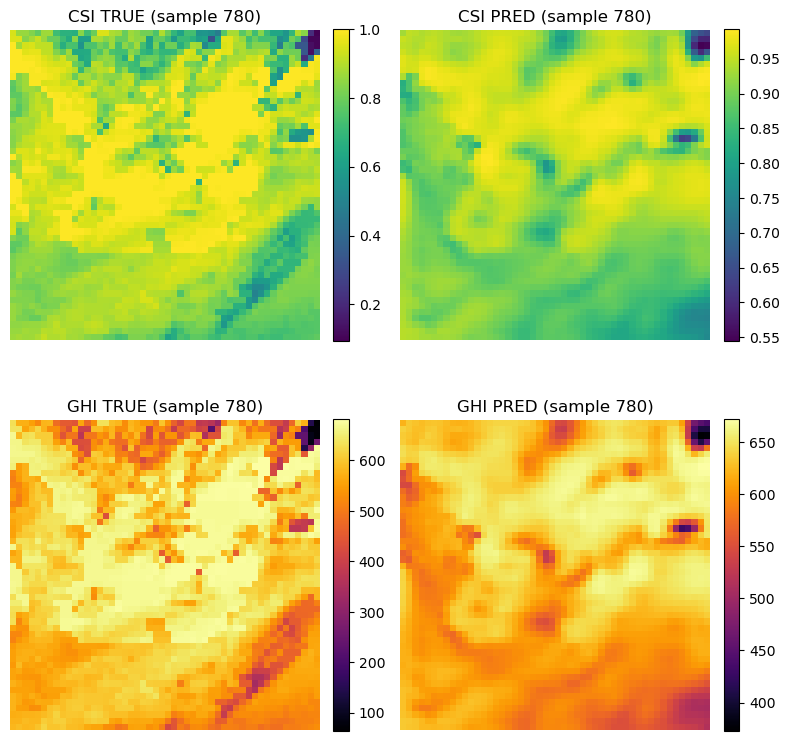

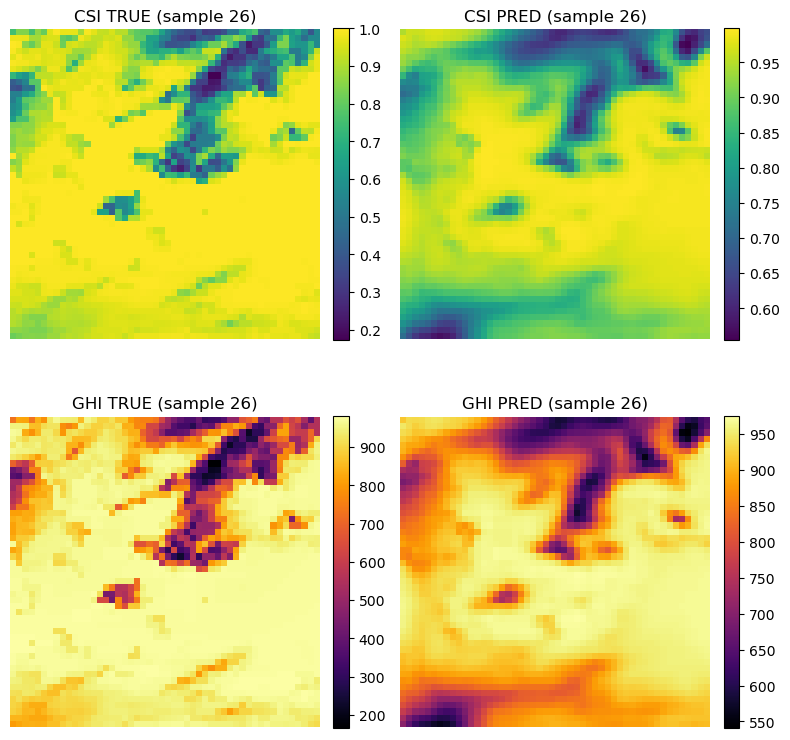

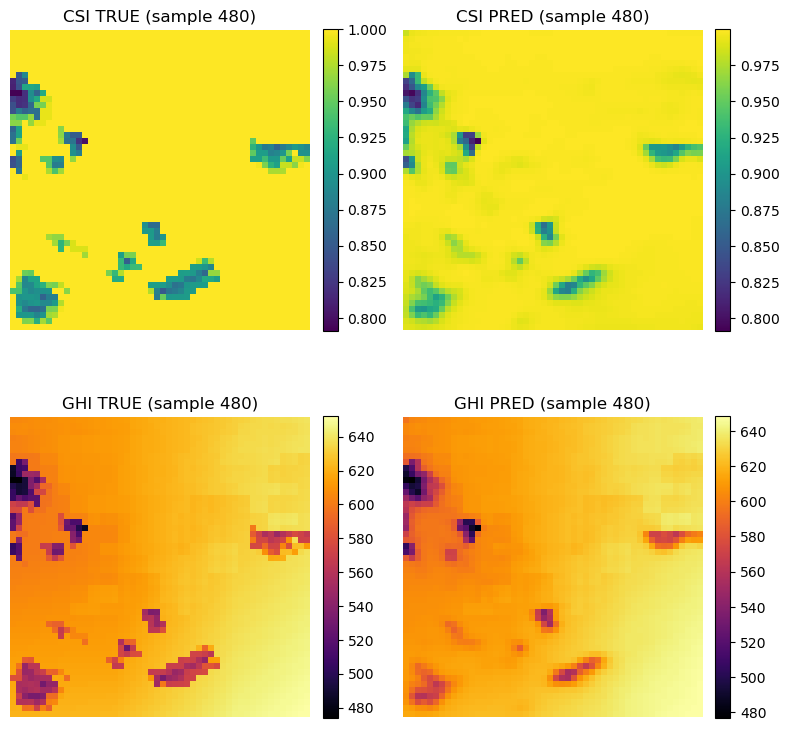

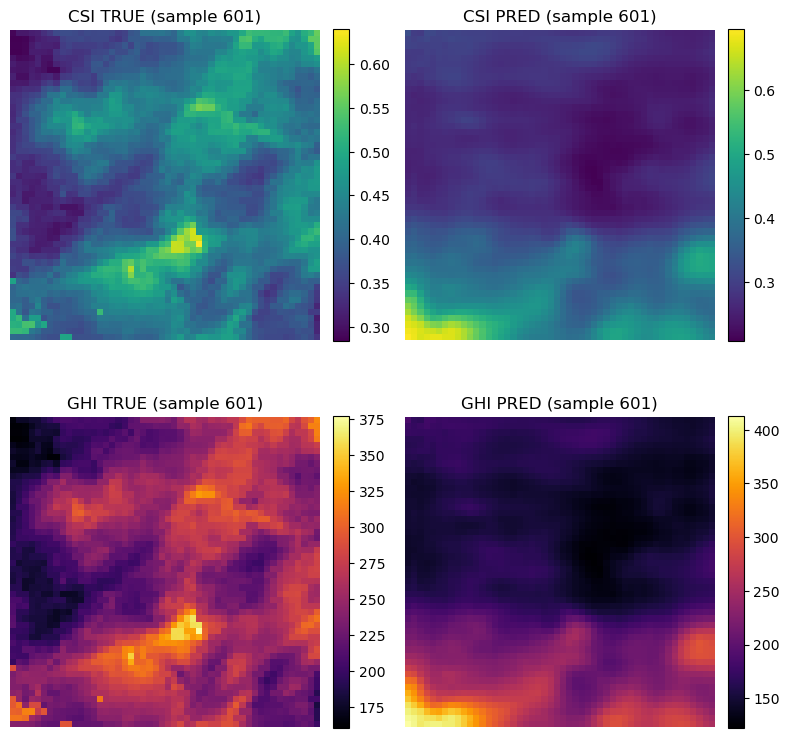

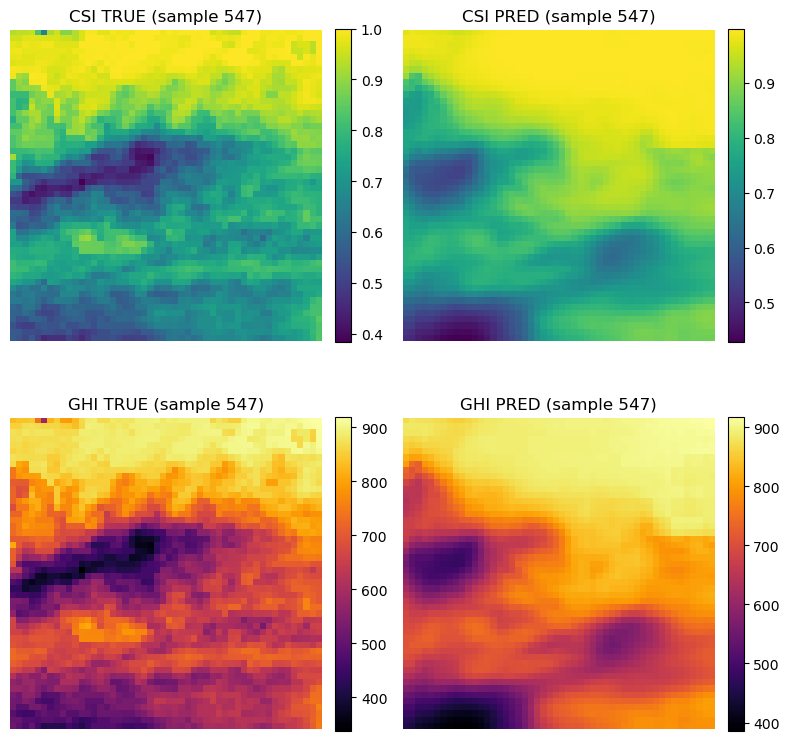

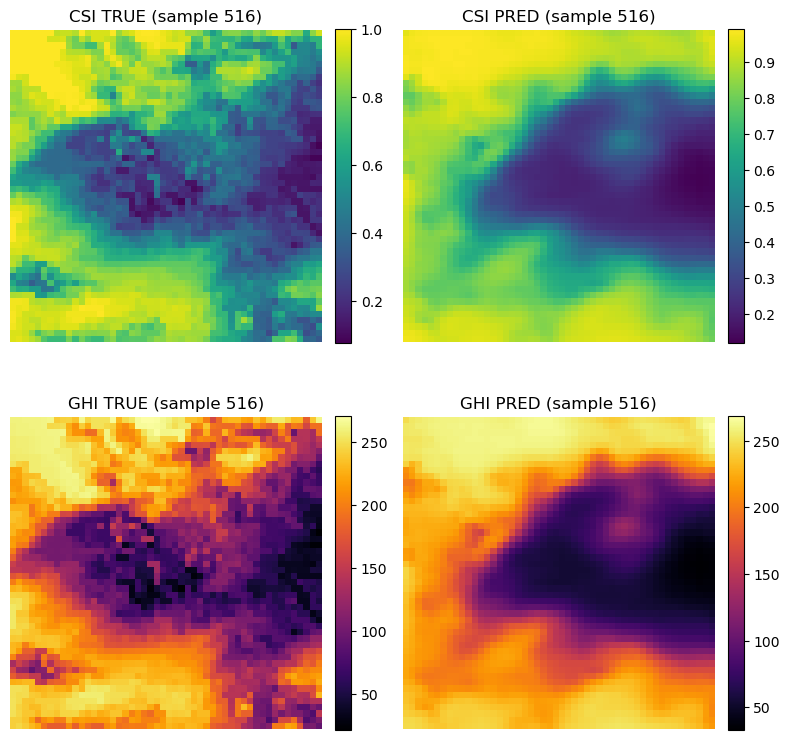

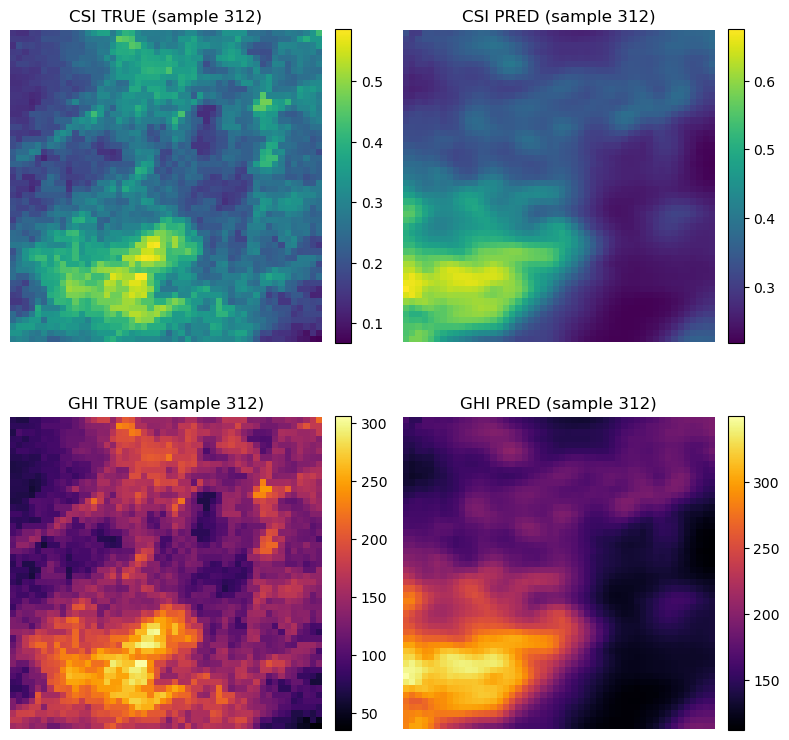

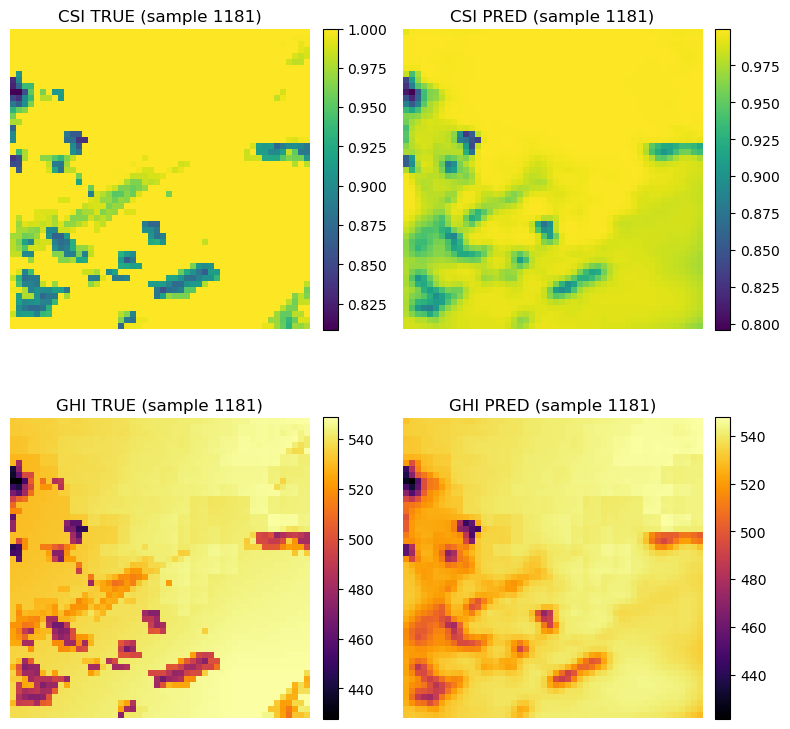

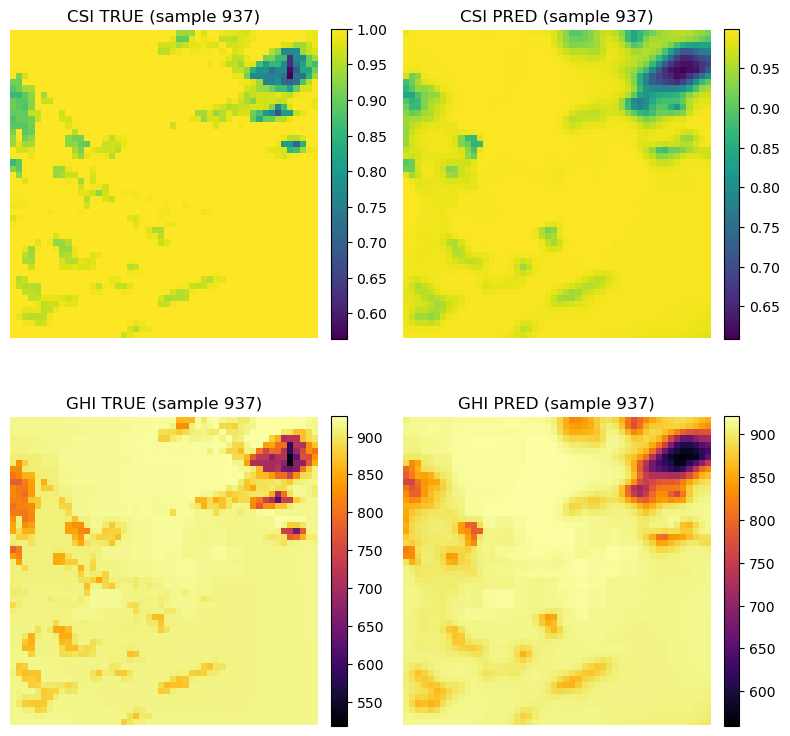

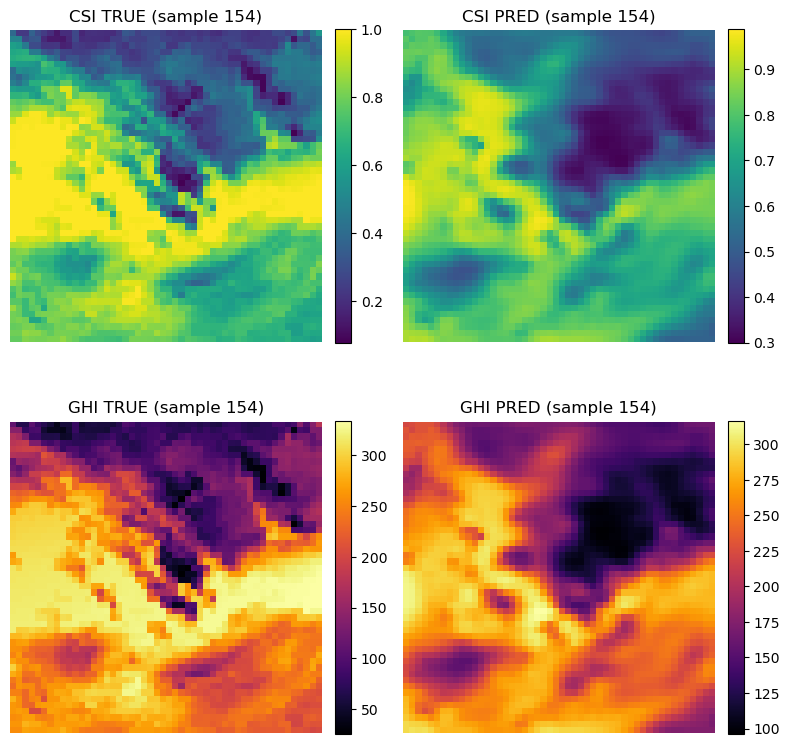

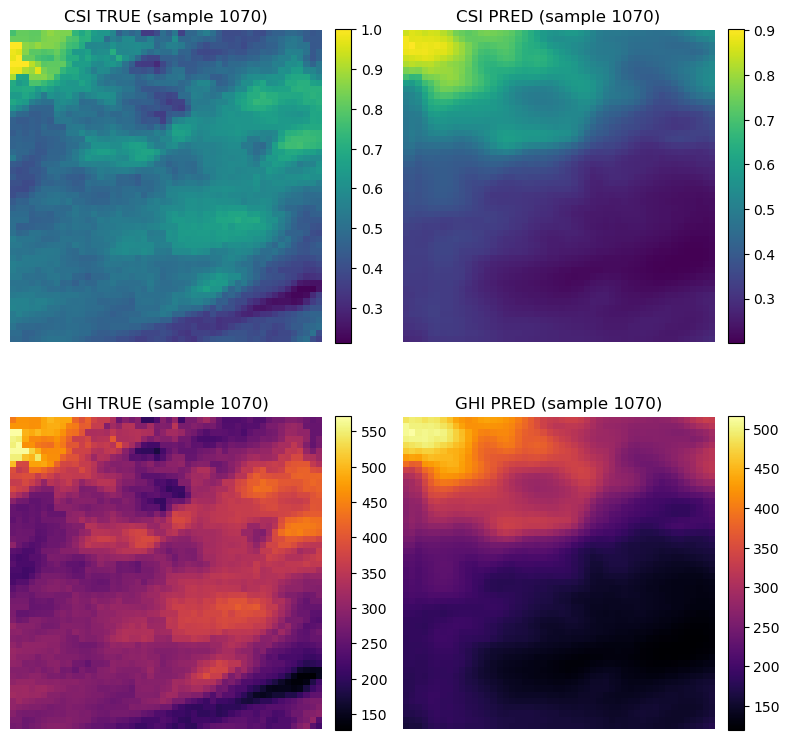

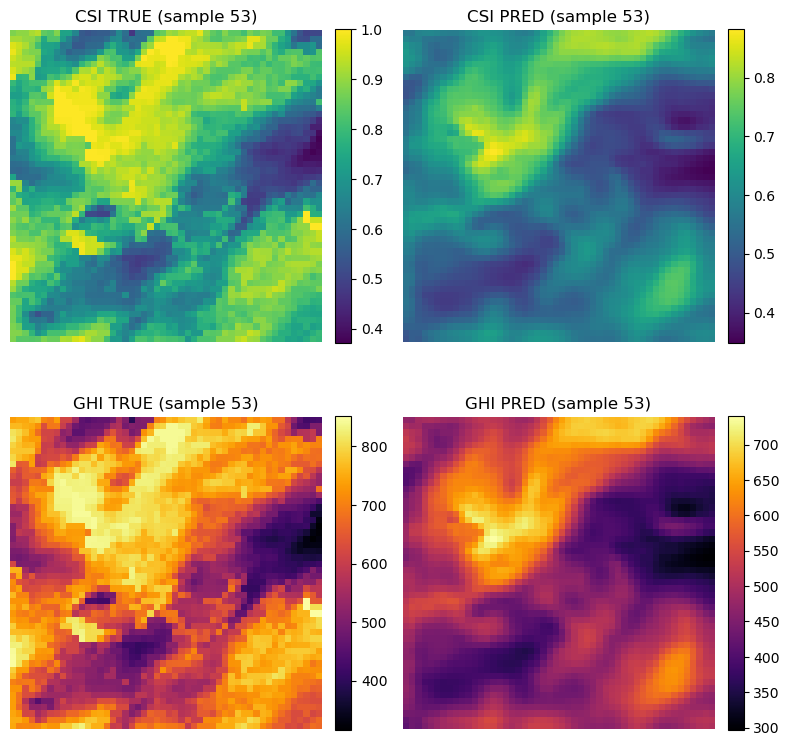

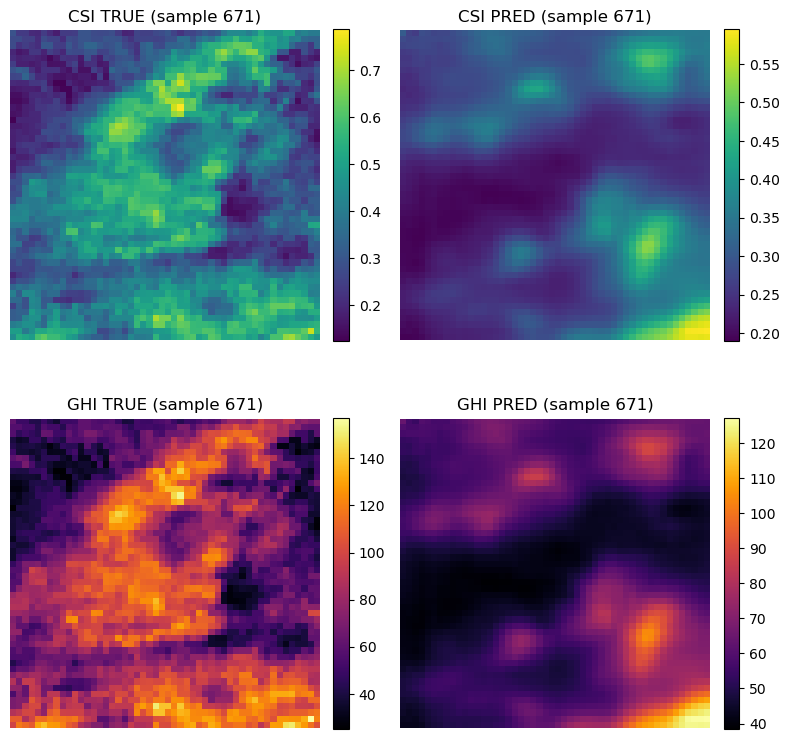

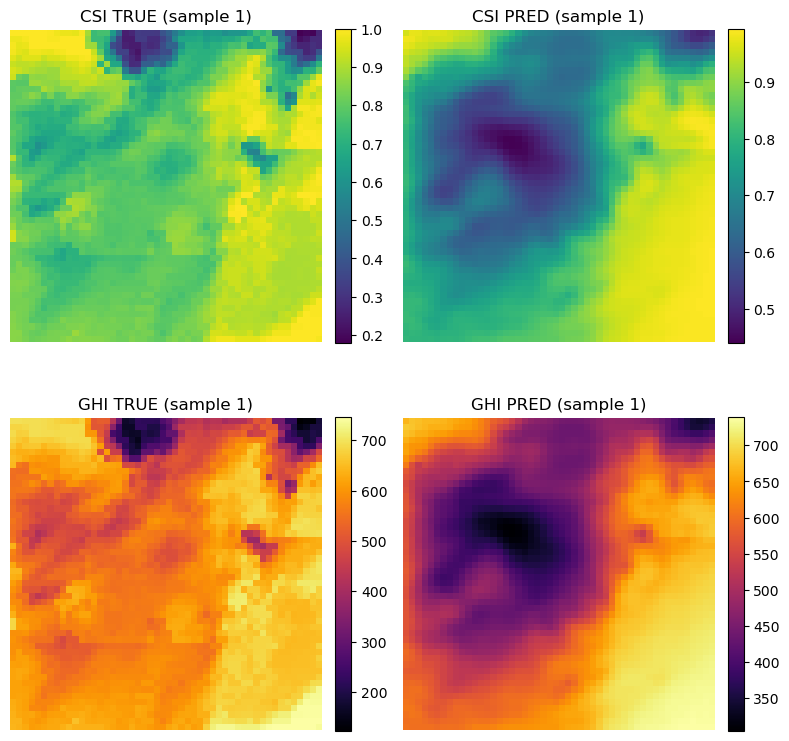

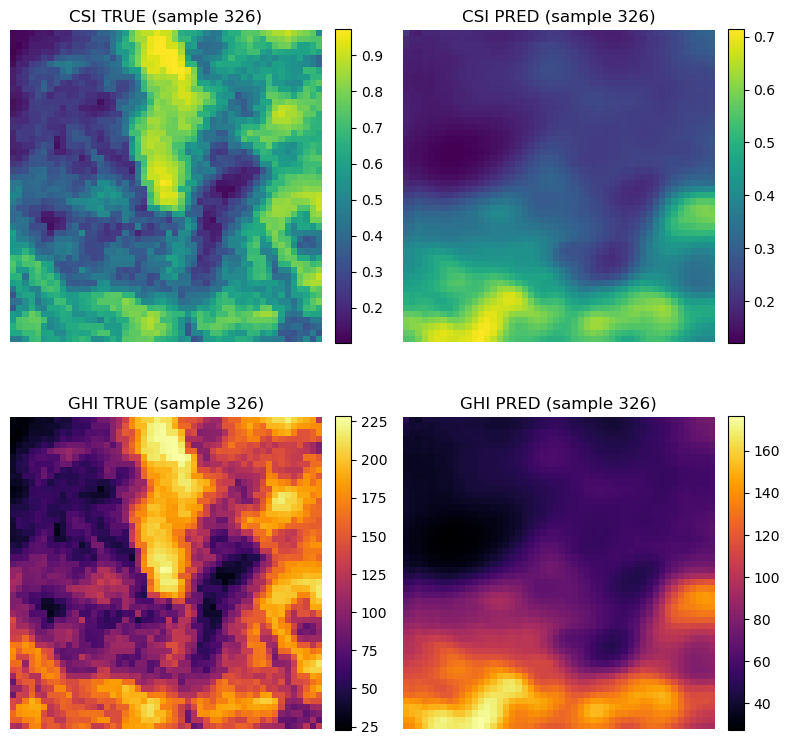

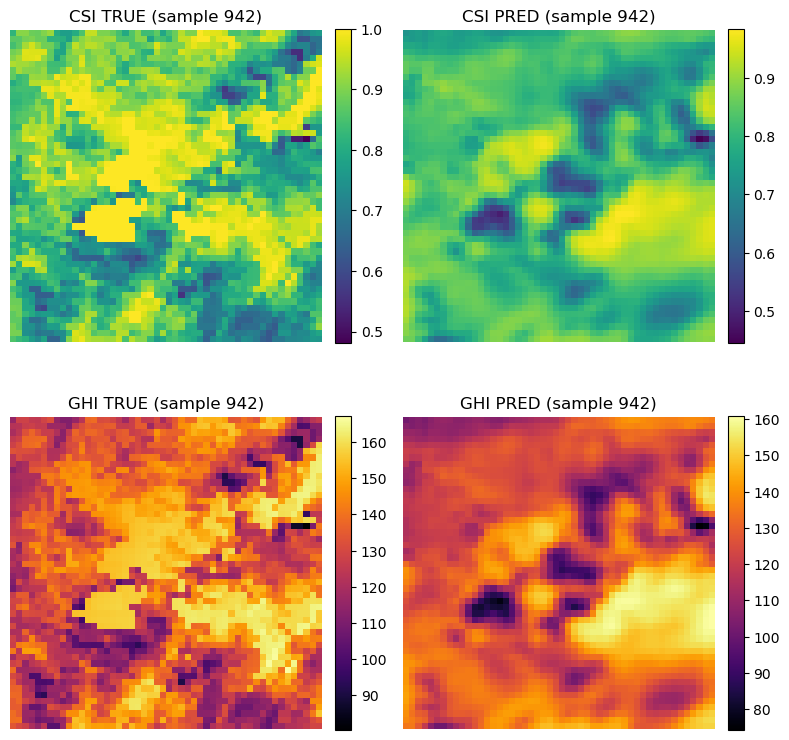

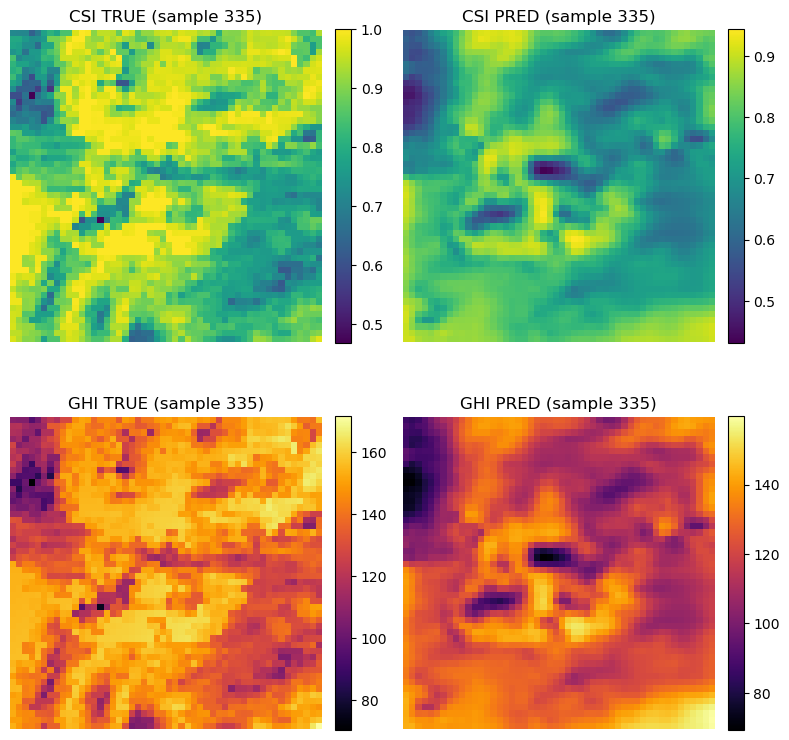

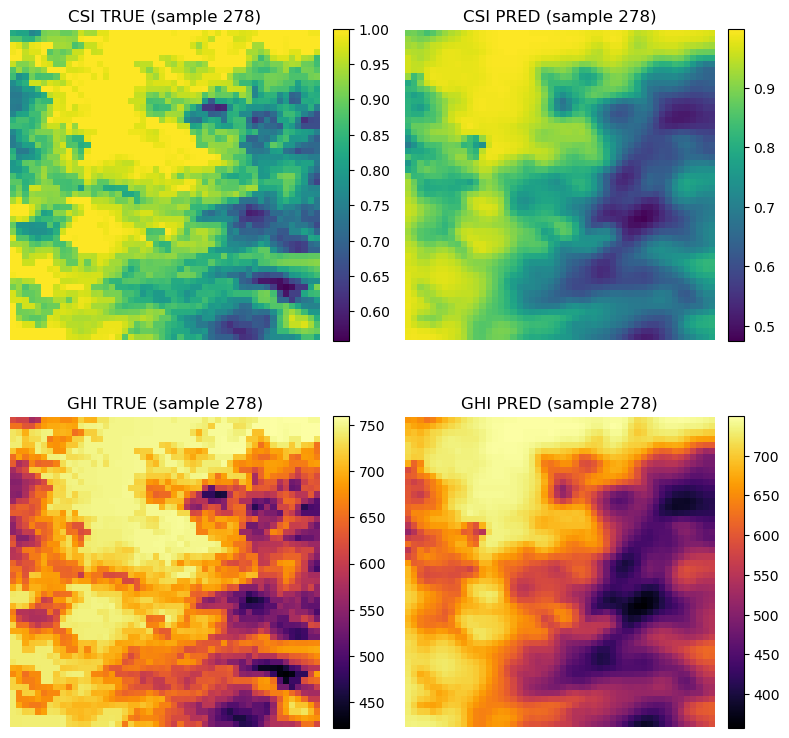

In [ ]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=30,
    seed=5

)
